In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=Warning)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv('users.csv')

In [3]:
df

,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,url,...,profile_background_image_url,profile_background_color,profile_link_color,utc_offset,protected,verified,description,updated,datasets,fake_status
0,3610511,Davide Dellacasa,braddd,20370,5470,2385,145,52,Fri Apr 06 10:58:22 +0000 2007,http://braddd.tumblr.com,...,http://a0.twimg.com/profile_background_images/...,BADFCD,FF0000,3600.0,NaN,NaN,Founder of http://www.screenweek.it & http://w...,2/14/2015 10:54,E13,0
1,5656162,Simone Economo,eKoeS,3131,506,381,9,40,Mon Apr 30 15:08:42 +0000 2007,http://www.lineheight.net/,...,http://a0.twimg.com/images/themes/theme1/bg.png,C0DEED,0084B4,3600.0,NaN,NaN,BSc degree (cum laude) in Computer Engineering...,2/14/2015 10:54,E13,0
2,5682702,tacone,tacone_,4024,264,87,323,16,Tue May 01 11:53:40 +0000 2007,http://t.co/LKrl1dZE,...,http://a0.twimg.com/profile_background_images/...,1A1B1F,2FC2EF,3600.0,NaN,NaN,Cogito ergo bestemmio.,2/14/2015 10:54,E13,0
3,6067292,alesaura,alesstar,40586,640,622,1118,32,Tue May 15 16:55:16 +0000 2007,http://alesstar.wordpress.com/,...,http://a0.twimg.com/images/themes/theme4/bg.gif,0099B9,0099B9,3600.0,NaN,NaN,"Se la vita ti dà sarde, scapocciale!",2/14/2015 10:54,E13,0
4,6015122,Angelo,PerDiletto,2016,62,64,13,0,Sun May 13 19:52:00 +0000 2007,http://www.flickr.com/per_diletto,...,http://a0.twimg.com/images/themes/theme18/bg.gif,ACDED6,38543,3600.0,NaN,NaN,Je me souviens,2/14/2015 10:54,E13,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1476,1127280169,Frilaif Official,frilaif,49,208,124,14,2,Mon Jan 28 07:13:47 +0000 2013,http://t.co/IkqfPF32pr,...,http://a0.twimg.com/images/themes/theme1/bg.png,C0DEED,0084B4,NaN,NaN,NaN,Sex and Erotic Advisor. Sexual health is a sta...,2/14/2015 10:54,E13,1
1477,1156344000,♔♥HeartsQueen♥♔,Stronzetta__,66,22,55,0,0,Thu Feb 07 07:27:08 +0000 2013,NaN,...,http://a0.twimg.com/images/themes/theme10/bg.gif,642D8B,740CC4,NaN,NaN,NaN,Se avessi seguito tutte le regole non sarei ma...,2/14/2015 10:54,E13,1
1478,1169114810,angelagervasi,angelagervasi2,4,0,4,3,0,Mon Feb 11 14:50:19 +0000 2013,NaN,...,http://a0.twimg.com/images/themes/theme1/bg.png,C0DEED,0084B4,NaN,NaN,NaN,"mamma e giovane nonna,laureata,amante del teat...",2/14/2015 10:54,E13,0
1479,1212975186,Midnight,Movie1O,3,2,4,0,0,Sat Feb 23 17:46:55 +0000 2013,NaN,...,http://a0.twimg.com/profile_background_images/...,FFFFFF,0,NaN,NaN,NaN,"If you don't shut your fucking mouth, I will k...",2/14/2015 10:54,E13,1


In [4]:
df.head()

,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,url,...,profile_background_image_url,profile_background_color,profile_link_color,utc_offset,protected,verified,description,updated,datasets,fake_status
0,3610511,Davide Dellacasa,braddd,20370,5470,2385,145,52,Fri Apr 06 10:58:22 +0000 2007,http://braddd.tumblr.com,...,http://a0.twimg.com/profile_background_images/...,BADFCD,FF0000,3600.0,NaN,NaN,Founder of http://www.screenweek.it & http://w...,2/14/2015 10:54,E13,0
1,5656162,Simone Economo,eKoeS,3131,506,381,9,40,Mon Apr 30 15:08:42 +0000 2007,http://www.lineheight.net/,...,http://a0.twimg.com/images/themes/theme1/bg.png,C0DEED,0084B4,3600.0,NaN,NaN,BSc degree (cum laude) in Computer Engineering...,2/14/2015 10:54,E13,0
2,5682702,tacone,tacone_,4024,264,87,323,16,Tue May 01 11:53:40 +0000 2007,http://t.co/LKrl1dZE,...,http://a0.twimg.com/profile_background_images/...,1A1B1F,2FC2EF,3600.0,NaN,NaN,Cogito ergo bestemmio.,2/14/2015 10:54,E13,0
3,6067292,alesaura,alesstar,40586,640,622,1118,32,Tue May 15 16:55:16 +0000 2007,http://alesstar.wordpress.com/,...,http://a0.twimg.com/images/themes/theme4/bg.gif,0099B9,0099B9,3600.0,NaN,NaN,"Se la vita ti dà sarde, scapocciale!",2/14/2015 10:54,E13,0
4,6015122,Angelo,PerDiletto,2016,62,64,13,0,Sun May 13 19:52:00 +0000 2007,http://www.flickr.com/per_diletto,...,http://a0.twimg.com/images/themes/theme18/bg.gif,ACDED6,38543,3600.0,NaN,NaN,Je me souviens,2/14/2015 10:54,E13,0


In [5]:
df.tail()

,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,url,...,profile_background_image_url,profile_background_color,profile_link_color,utc_offset,protected,verified,description,updated,datasets,fake_status
1476,1127280169,Frilaif Official,frilaif,49,208,124,14,2,Mon Jan 28 07:13:47 +0000 2013,http://t.co/IkqfPF32pr,...,http://a0.twimg.com/images/themes/theme1/bg.png,C0DEED,0084B4,NaN,NaN,NaN,Sex and Erotic Advisor. Sexual health is a sta...,2/14/2015 10:54,E13,1
1477,1156344000,♔♥HeartsQueen♥♔,Stronzetta__,66,22,55,0,0,Thu Feb 07 07:27:08 +0000 2013,NaN,...,http://a0.twimg.com/images/themes/theme10/bg.gif,642D8B,740CC4,NaN,NaN,NaN,Se avessi seguito tutte le regole non sarei ma...,2/14/2015 10:54,E13,1
1478,1169114810,angelagervasi,angelagervasi2,4,0,4,3,0,Mon Feb 11 14:50:19 +0000 2013,NaN,...,http://a0.twimg.com/images/themes/theme1/bg.png,C0DEED,0084B4,NaN,NaN,NaN,"mamma e giovane nonna,laureata,amante del teat...",2/14/2015 10:54,E13,0
1479,1212975186,Midnight,Movie1O,3,2,4,0,0,Sat Feb 23 17:46:55 +0000 2013,NaN,...,http://a0.twimg.com/profile_background_images/...,FFFFFF,0,NaN,NaN,NaN,"If you don't shut your fucking mouth, I will k...",2/14/2015 10:54,E13,1
1480,1213937306,ʸᵒᵘ,xjawaadscookie,2568,351,341,318,2,Sat Feb 23 23:17:08 +0000 2013,NaN,...,http://a0.twimg.com/profile_background_images/...,FFFFFF,2BF00C,3600.0,NaN,NaN,@onedirection I JUST WANNA SAY A MASSIVE THANK...,2/14/2015 10:54,E13,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1481 entries, 0 to 1480
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  1481 non-null   int64  
 1   name                                1481 non-null   object 
 2   screen_name                         1481 non-null   object 
 3   statuses_count                      1481 non-null   int64  
 4   followers_count                     1481 non-null   int64  
 5   friends_count                       1481 non-null   int64  
 6   favourites_count                    1481 non-null   int64  
 7   listed_count                        1481 non-null   int64  
 8   created_at                          1481 non-null   object 
 9   url                                 463 non-null    object 
 10  lang                                1481 non-null   object 
 11  time_zone                           1063 no

In [7]:
df.describe()

,id,statuses_count,followers_count,friends_count,favourites_count,listed_count,default_profile,default_profile_image,geo_enabled,profile_use_background_image,profile_background_tile,utc_offset,protected,verified,fake_status
count,1.481000e+03,1481.000000,1481.000000,1481.000000,1481.000000,1481.000000,397.0,4.0,719.0,1423.0,486.0,1063.000000,0.0,0.0,1481.000000
mean,4.000432e+08,3140.782579,690.922350,403.128292,439.611749,5.360567,1.0,1.0,1.0,1.0,1.0,1535.841957,NaN,NaN,0.510466
std,2.961304e+08,6391.957957,11058.508986,610.572368,1970.556008,32.183232,0.0,0.0,0.0,0.0,0.0,7805.690161,NaN,NaN,0.500059
min,3.610511e+06,3.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.0,1.0,1.0,1.0,-39600.000000,NaN,NaN,0.000000
25%,1.572905e+08,315.000000,45.000000,115.000000,4.000000,0.000000,1.0,1.0,1.0,1.0,1.0,3600.000000,NaN,NaN,0.000000
50%,3.822478e+08,992.000000,102.000000,226.000000,29.000000,1.000000,1.0,1.0,1.0,1.0,1.0,3600.000000,NaN,NaN,1.000000
75%,5.229255e+08,3029.000000,259.000000,437.000000,176.000000,2.000000,1.0,1.0,1.0,1.0,1.0,3600.000000,NaN,NaN,1.000000
max,1.219743e+09,79876.000000,408372.000000,12773.000000,44349.000000,744.000000,1.0,1.0,1.0,1.0,1.0,36000.000000,NaN,NaN,1.000000


In [8]:
df.shape

(1481, 35)

In [9]:
df.isnull().sum()

id                                       0
name                                     0
screen_name                              0
statuses_count                           0
followers_count                          0
friends_count                            0
favourites_count                         0
listed_count                             0
created_at                               0
url                                   1018
lang                                     0
time_zone                              418
location                               492
default_profile                       1084
default_profile_image                 1477
geo_enabled                            762
profile_image_url                        0
profile_banner_url                     496
profile_use_background_image            58
profile_background_image_url_https       0
profile_text_color                       0
profile_image_url_https                  0
profile_sidebar_border_color             0
profile_bac

In [10]:
data=df.drop("url", axis=1)

In [11]:
columns_to_drop = ["url", "protected", "time_zone","location","updated"]
data = df.drop(columns=columns_to_drop)

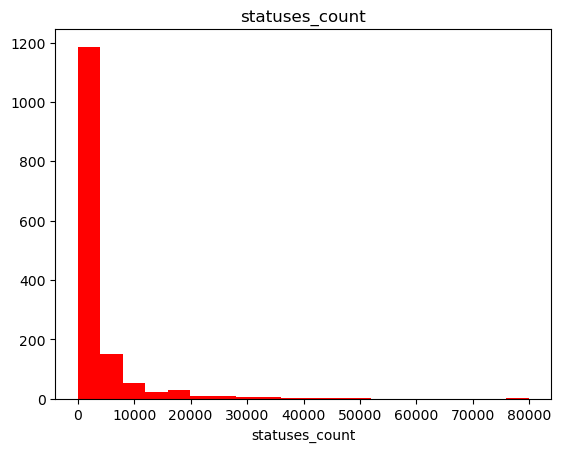

In [12]:
plt.hist(data.statuses_count, bins=20, color='r')
plt.title('statuses_count')
plt.xlabel('statuses_count')
plt.show()

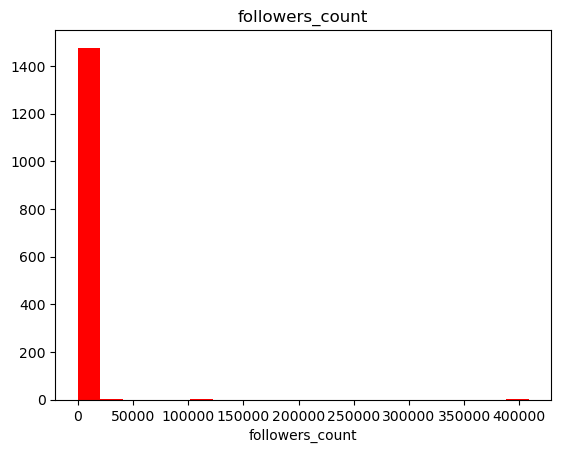

In [13]:
plt.hist(data.followers_count, bins=20, color='r')
plt.title('followers_count')
plt.xlabel('followers_count')
plt.show()

<Figure size 1000x800 with 0 Axes>

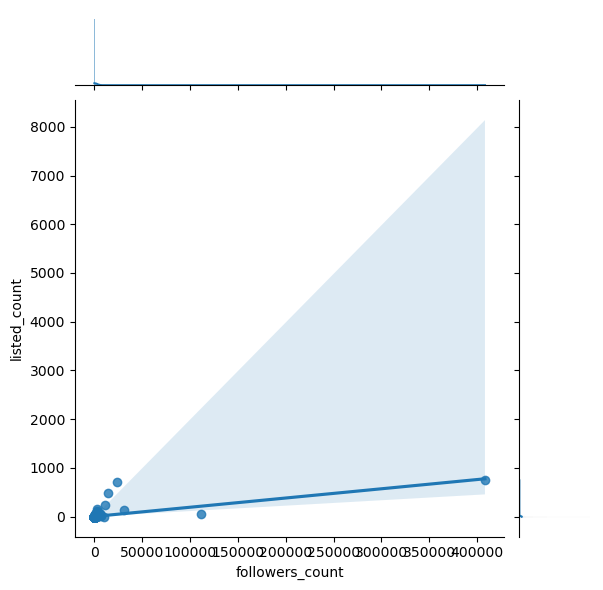

In [14]:
plt.figure(figsize = (10,8))
sns.jointplot(x = df['followers_count'] ,y = df['listed_count'] , kind = 'reg')
plt.show()

In [15]:
data


,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,lang,...,profile_background_tile,profile_sidebar_fill_color,profile_background_image_url,profile_background_color,profile_link_color,utc_offset,verified,description,datasets,fake_status
0,3610511,Davide Dellacasa,braddd,20370,5470,2385,145,52,Fri Apr 06 10:58:22 +0000 2007,it,...,NaN,FFF7CC,http://a0.twimg.com/profile_background_images/...,BADFCD,FF0000,3600.0,NaN,Founder of http://www.screenweek.it & http://w...,E13,0
1,5656162,Simone Economo,eKoeS,3131,506,381,9,40,Mon Apr 30 15:08:42 +0000 2007,en,...,NaN,DDEEF6,http://a0.twimg.com/images/themes/theme1/bg.png,C0DEED,0084B4,3600.0,NaN,BSc degree (cum laude) in Computer Engineering...,E13,0
2,5682702,tacone,tacone_,4024,264,87,323,16,Tue May 01 11:53:40 +0000 2007,en,...,1.0,0,http://a0.twimg.com/profile_background_images/...,1A1B1F,2FC2EF,3600.0,NaN,Cogito ergo bestemmio.,E13,0
3,6067292,alesaura,alesstar,40586,640,622,1118,32,Tue May 15 16:55:16 +0000 2007,en,...,NaN,95E8EC,http://a0.twimg.com/images/themes/theme4/bg.gif,0099B9,0099B9,3600.0,NaN,"Se la vita ti dà sarde, scapocciale!",E13,0
4,6015122,Angelo,PerDiletto,2016,62,64,13,0,Sun May 13 19:52:00 +0000 2007,it,...,NaN,F6F6F6,http://a0.twimg.com/images/themes/theme18/bg.gif,ACDED6,38543,3600.0,NaN,Je me souviens,E13,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1476,1127280169,Frilaif Official,frilaif,49,208,124,14,2,Mon Jan 28 07:13:47 +0000 2013,it,...,NaN,DDEEF6,http://a0.twimg.com/images/themes/theme1/bg.png,C0DEED,0084B4,NaN,NaN,Sex and Erotic Advisor. Sexual health is a sta...,E13,1
1477,1156344000,♔♥HeartsQueen♥♔,Stronzetta__,66,22,55,0,0,Thu Feb 07 07:27:08 +0000 2013,it,...,1.0,7AC3EE,http://a0.twimg.com/images/themes/theme10/bg.gif,642D8B,740CC4,NaN,NaN,Se avessi seguito tutte le regole non sarei ma...,E13,1
1478,1169114810,angelagervasi,angelagervasi2,4,0,4,3,0,Mon Feb 11 14:50:19 +0000 2013,it,...,NaN,DDEEF6,http://a0.twimg.com/images/themes/theme1/bg.png,C0DEED,0084B4,NaN,NaN,"mamma e giovane nonna,laureata,amante del teat...",E13,0
1479,1212975186,Midnight,Movie1O,3,2,4,0,0,Sat Feb 23 17:46:55 +0000 2013,it,...,NaN,F6FFD1,http://a0.twimg.com/profile_background_images/...,FFFFFF,0,NaN,NaN,"If you don't shut your fucking mouth, I will k...",E13,1


In [16]:
from sklearn import preprocessing

# label_encoder object knows
# how to understand word labels.
label_encoder = preprocessing.LabelEncoder()
#Encoding data
labelDict = {}
for feature in data:
    le = preprocessing.LabelEncoder()
    le.fit(data[feature])
    le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    data[feature] = le.transform(data[feature])
    # Get labels
    labelKey = 'label_' + feature
    labelValue = [*le_name_mapping]
    labelDict[labelKey] =labelValue

for key, value in labelDict.items():
    print(key, value)

label_id [np.int64(3610511), np.int64(5656162), np.int64(5682702), np.int64(6015122), np.int64(6067292), np.int64(6134312), np.int64(6140012), np.int64(6684602), np.int64(7046912), np.int64(7470952), np.int64(8072492), np.int64(8291932), np.int64(8858022), np.int64(8927532), np.int64(8933252), np.int64(9011502), np.int64(9351052), np.int64(9564632), np.int64(9939012), np.int64(9993142), np.int64(10492262), np.int64(11176152), np.int64(13260592), np.int64(14057516), np.int64(14112759), np.int64(14492555), np.int64(14709812), np.int64(14865840), np.int64(14958182), np.int64(15016610), np.int64(15271419), np.int64(15350901), np.int64(15391421), np.int64(15836275), np.int64(15873303), np.int64(16043064), np.int64(16093829), np.int64(16591972), np.int64(16927266), np.int64(17654864), np.int64(17852114), np.int64(18173213), np.int64(18527544), np.int64(18671285), np.int64(18735790), np.int64(18800245), np.int64(19598248), np.int64(20308222), np.int64(21102000), np.int64(21770069), np.int64(2

In [17]:
data

,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,lang,...,profile_background_tile,profile_sidebar_fill_color,profile_background_image_url,profile_background_color,profile_link_color,utc_offset,verified,description,datasets,fake_status
0,0,288,858,1175,531,682,133,46,0,5,...,1,173,46,159,356,8,0,400,0,0
1,1,1074,949,859,358,342,9,39,227,1,...,1,108,0,165,10,8,0,188,0,0
2,2,1430,1422,921,241,75,224,16,1190,1,...,0,0,37,55,112,8,0,257,0,0
3,4,1195,784,1206,392,468,364,32,1202,1,...,1,65,13,5,17,8,0,937,0,0
4,3,115,568,737,62,52,13,0,772,5,...,1,151,9,152,123,8,0,588,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1476,1453,476,1015,36,200,112,14,2,319,5,...,1,108,0,165,10,13,0,957,0,1
1477,1462,1466,686,49,22,44,0,0,893,5,...,0,56,1,112,192,13,0,934,0,1
1478,1464,1208,806,1,0,1,3,0,279,5,...,1,108,0,165,10,13,0,1330,0,0
1479,1475,868,523,0,2,1,0,0,518,5,...,1,152,704,271,0,13,0,508,0,1


In [18]:
data.head(50)

,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,lang,...,profile_background_tile,profile_sidebar_fill_color,profile_background_image_url,profile_background_color,profile_link_color,utc_offset,verified,description,datasets,fake_status
0,0,288,858,1175,531,682,133,46,0,5,...,1,173,46,159,356,8,0,400,0,0
1,1,1074,949,859,358,342,9,39,227,1,...,1,108,0,165,10,8,0,188,0,0
2,2,1430,1422,921,241,75,224,16,1190,1,...,0,0,37,55,112,8,0,257,0,0
3,4,1195,784,1206,392,468,364,32,1202,1,...,1,65,13,5,17,8,0,937,0,0
4,3,115,568,737,62,52,13,0,772,5,...,1,151,9,152,123,8,0,588,0,0
5,6,174,906,894,137,167,53,1,144,5,...,0,105,552,177,78,8,0,1066,0,0
6,5,1436,1435,576,128,156,2,5,143,1,...,0,138,5,39,232,8,0,463,0,0
7,7,1316,355,1025,449,653,301,5,108,5,...,1,151,9,152,123,8,0,635,0,0
8,8,760,1198,1116,537,566,300,63,751,1,...,1,176,0,36,48,8,0,399,0,0
9,9,138,1319,1114,413,504,314,27,550,5,...,0,103,309,39,232,8,0,1002,0,0


In [19]:
data.tail(50)

,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,lang,...,profile_background_tile,profile_sidebar_fill_color,profile_background_image_url,profile_background_color,profile_link_color,utc_offset,verified,description,datasets,fake_status
1431,422,282,928,601,269,310,15,0,441,1,...,1,151,696,43,123,7,0,86,0,1
1432,438,941,1427,199,21,39,32,0,175,5,...,1,108,0,165,10,8,0,1132,0,1
1433,474,547,669,657,290,374,106,0,167,1,...,1,176,4,155,223,8,0,491,0,1
1434,482,1171,547,1063,152,186,362,2,27,5,...,1,151,497,271,302,8,0,694,0,1
1435,500,684,1257,853,338,465,283,11,1109,2,...,0,26,316,55,112,9,0,1199,0,1
1436,519,875,1259,14,6,20,4,0,693,5,...,0,108,284,24,134,8,0,503,0,1
1437,529,1433,1455,988,166,237,304,1,1097,5,...,1,0,671,0,262,6,0,465,0,1
1438,532,281,923,224,250,137,31,7,287,1,...,1,65,13,5,17,8,0,29,0,1
1439,565,770,1187,794,162,163,325,8,845,5,...,1,26,18,55,112,6,0,166,0,1
1440,594,1105,1432,615,170,57,3,10,373,5,...,1,108,0,165,10,8,0,1148,0,1


In [20]:
data.corr()

,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,lang,...,profile_background_tile,profile_sidebar_fill_color,profile_background_image_url,profile_background_color,profile_link_color,utc_offset,verified,description,datasets,fake_status
id,1.000000,0.002426,-0.103715,-0.330349,-0.233402,-0.204601,-0.007648,-0.264747,0.009093,0.351406,...,0.065207,0.006902,0.000800,0.104765,-0.112019,0.341120,NaN,0.032742,NaN,0.012840
name,0.002426,1.000000,0.412763,0.070081,0.058977,0.048256,0.069524,0.025024,0.021993,0.046619,...,0.003272,-0.004280,0.022320,0.000796,-0.048919,0.027208,NaN,0.100296,NaN,0.028024
screen_name,-0.103715,0.412763,1.000000,0.092627,0.061998,0.054376,0.025463,0.068434,-0.018374,-0.046050,...,0.052957,0.011583,-0.002425,-0.017844,-0.034599,-0.048079,NaN,0.081621,NaN,-0.027850
statuses_count,-0.330349,0.070081,0.092627,1.000000,0.719166,0.554752,0.584260,0.455886,0.003389,-0.083576,...,-0.143691,0.028345,0.158448,-0.027190,0.124830,-0.269889,NaN,-0.029463,NaN,0.020383
followers_count,-0.233402,0.058977,0.061998,0.719166,1.000000,0.761741,0.525048,0.654034,-0.027939,-0.068912,...,-0.116476,0.050926,0.152592,0.014396,0.092190,-0.192171,NaN,-0.047591,NaN,-0.005116
friends_count,-0.204601,0.048256,0.054376,0.554752,0.761741,1.000000,0.396010,0.374375,-0.053002,-0.035657,...,-0.118655,0.003730,0.126381,-0.018372,0.068990,-0.153077,NaN,-0.006815,NaN,-0.029650
favourites_count,-0.007648,0.069524,0.025463,0.584260,0.525048,0.396010,1.000000,0.292899,-0.026415,0.036502,...,-0.111538,0.023560,0.222277,0.026381,0.116518,-0.120888,NaN,0.001119,NaN,0.022779
listed_count,-0.264747,0.025024,0.068434,0.455886,0.654034,0.374375,0.292899,1.000000,-0.016332,-0.181945,...,-0.011075,0.043680,0.044068,0.010340,0.058233,-0.142860,NaN,-0.031976,NaN,-0.010861
created_at,0.009093,0.021993,-0.018374,0.003389,-0.027939,-0.053002,-0.026415,-0.016332,1.000000,-0.030814,...,-0.054776,-0.009032,0.018850,-0.007689,-0.047809,-0.038348,NaN,-0.012895,NaN,0.027332
lang,0.351406,0.046619,-0.046050,-0.083576,-0.068912,-0.035657,0.036502,-0.181945,-0.030814,1.000000,...,-0.020394,-0.001471,0.039678,0.029520,-0.007529,0.128540,NaN,0.020058,NaN,0.010876


In [21]:
data=data.drop("datasets",axis=1)

In [22]:
data=data.drop("verified",axis=1)


In [23]:
#data=data.drop("created_at",axis=1)

In [24]:
data=data.drop("profile_background_tile",axis=1)

In [25]:
data=data.drop("profile_sidebar_fill_color",axis=1)

In [26]:
data=data.drop("profile_background_image_url",axis=1)

In [27]:
#data=data.drop("profile_link_color",axis=1)

In [28]:
data=data.drop("utc_offset",axis=1)

In [29]:
data

,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,lang,...,profile_banner_url,profile_use_background_image,profile_background_image_url_https,profile_text_color,profile_image_url_https,profile_sidebar_border_color,profile_background_color,profile_link_color,description,fake_status
0,0,288,858,1175,531,682,133,46,0,5,...,391,0,45,7,77,109,159,356,400,0
1,1,1074,949,859,358,342,9,39,227,1,...,985,0,0,42,235,125,165,10,188,0
2,2,1430,1422,921,241,75,224,16,1190,1,...,713,0,37,77,107,11,55,112,257,0
3,4,1195,784,1206,392,468,364,32,1202,1,...,746,0,13,48,525,125,5,17,937,0
4,3,115,568,737,62,52,13,0,772,5,...,985,0,9,42,0,105,152,123,588,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1476,1453,476,1015,36,200,112,14,2,319,5,...,65,0,0,42,872,75,165,10,957,1
1477,1462,1466,686,49,22,44,0,0,893,5,...,77,0,1,50,922,125,112,192,934,1
1478,1464,1208,806,1,0,1,3,0,279,5,...,985,0,0,42,1394,75,165,10,1330,0
1479,1475,868,523,0,2,1,0,0,518,5,...,94,1,662,42,1210,125,271,0,508,1


In [30]:
data=data.drop("profile_banner_url",axis=1)

In [31]:
data=data.drop("profile_image_url",axis=1)

In [32]:
data=data.drop("profile_text_color",axis=1)

In [33]:
data=data.drop("profile_image_url_https",axis=1)

In [34]:
data

,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,lang,default_profile,default_profile_image,geo_enabled,profile_use_background_image,profile_background_image_url_https,profile_sidebar_border_color,profile_background_color,profile_link_color,description,fake_status
0,0,288,858,1175,531,682,133,46,0,5,1,1,1,0,45,109,159,356,400,0
1,1,1074,949,859,358,342,9,39,227,1,1,1,1,0,0,125,165,10,188,0
2,2,1430,1422,921,241,75,224,16,1190,1,1,1,1,0,37,11,55,112,257,0
3,4,1195,784,1206,392,468,364,32,1202,1,1,1,0,0,13,125,5,17,937,0
4,3,115,568,737,62,52,13,0,772,5,1,1,0,0,9,105,152,123,588,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1476,1453,476,1015,36,200,112,14,2,319,5,0,1,1,0,0,75,165,10,957,1
1477,1462,1466,686,49,22,44,0,0,893,5,1,1,1,0,1,125,112,192,934,1
1478,1464,1208,806,1,0,1,3,0,279,5,0,0,1,0,0,75,165,10,1330,0
1479,1475,868,523,0,2,1,0,0,518,5,1,1,1,1,662,125,271,0,508,1


In [35]:
data=data.drop("profile_sidebar_border_color",axis=1)

In [36]:
data=data.drop("profile_background_image_url_https",axis=1)

In [37]:
data.columns

Index(['id', 'name', 'screen_name', 'statuses_count', 'followers_count',
       'friends_count', 'favourites_count', 'listed_count', 'created_at',
       'lang', 'default_profile', 'default_profile_image', 'geo_enabled',
       'profile_use_background_image', 'profile_background_color',
       'profile_link_color', 'description', 'fake_status'],
      dtype='object')

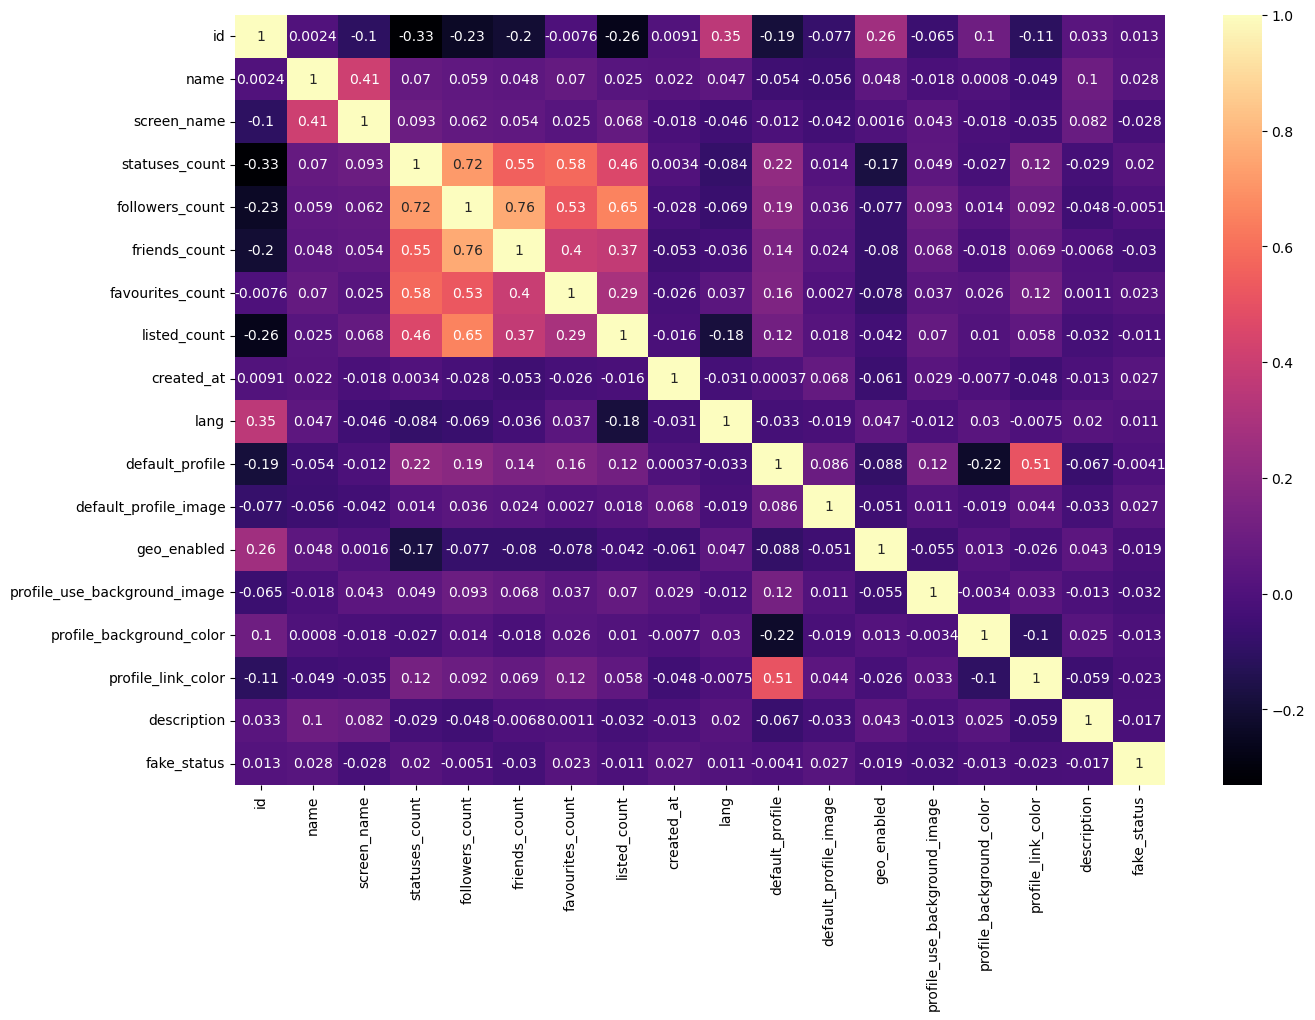

In [38]:
plt.figure(figsize = (15,10))
sns.heatmap(data.corr() , cmap = 'magma' , annot = True)
plt.show()

In [39]:
data.shape

(1481, 18)

In [40]:
data.head(50)

,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,lang,default_profile,default_profile_image,geo_enabled,profile_use_background_image,profile_background_color,profile_link_color,description,fake_status
0,0,288,858,1175,531,682,133,46,0,5,1,1,1,0,159,356,400,0
1,1,1074,949,859,358,342,9,39,227,1,1,1,1,0,165,10,188,0
2,2,1430,1422,921,241,75,224,16,1190,1,1,1,1,0,55,112,257,0
3,4,1195,784,1206,392,468,364,32,1202,1,1,1,0,0,5,17,937,0
4,3,115,568,737,62,52,13,0,772,5,1,1,0,0,152,123,588,0
5,6,174,906,894,137,167,53,1,144,5,1,1,0,0,177,78,1066,0
6,5,1436,1435,576,128,156,2,5,143,1,1,1,0,0,39,232,463,0
7,7,1316,355,1025,449,653,301,5,108,5,1,1,0,0,152,123,635,0
8,8,760,1198,1116,537,566,300,63,751,1,1,1,0,1,36,48,399,0
9,9,138,1319,1114,413,504,314,27,550,5,1,1,0,1,39,232,1002,0


In [41]:
data.tail(50)

,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,lang,default_profile,default_profile_image,geo_enabled,profile_use_background_image,profile_background_color,profile_link_color,description,fake_status
1431,422,282,928,601,269,310,15,0,441,1,1,1,1,1,43,123,86,1
1432,438,941,1427,199,21,39,32,0,175,5,0,1,0,0,165,10,1132,1
1433,474,547,669,657,290,374,106,0,167,1,1,1,1,0,155,223,491,1
1434,482,1171,547,1063,152,186,362,2,27,5,1,1,1,0,271,302,694,1
1435,500,684,1257,853,338,465,283,11,1109,2,1,1,1,0,55,112,1199,1
1436,519,875,1259,14,6,20,4,0,693,5,1,1,1,0,24,134,503,1
1437,529,1433,1455,988,166,237,304,1,1097,5,1,1,0,0,0,262,465,1
1438,532,281,923,224,250,137,31,7,287,1,1,1,0,0,5,17,29,1
1439,565,770,1187,794,162,163,325,8,845,5,1,1,0,0,55,112,166,1
1440,594,1105,1432,615,170,57,3,10,373,5,0,1,0,0,165,10,1148,1


In [42]:
data.columns

Index(['id', 'name', 'screen_name', 'statuses_count', 'followers_count',
       'friends_count', 'favourites_count', 'listed_count', 'created_at',
       'lang', 'default_profile', 'default_profile_image', 'geo_enabled',
       'profile_use_background_image', 'profile_background_color',
       'profile_link_color', 'description', 'fake_status'],
      dtype='object')

In [43]:
data=data.drop('id',axis=1)
data=data.drop('lang',axis=1)
data=data.drop('default_profile', axis=1)
data=data.drop('default_profile_image',axis=1)
data=data.drop('geo_enabled',axis=1)
data=data.drop('profile_use_background_image',axis=1)
data=data.drop('profile_background_color',axis=1)
data=data.drop('description',axis=1)

In [44]:
data

,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,profile_link_color,fake_status
0,288,858,1175,531,682,133,46,0,356,0
1,1074,949,859,358,342,9,39,227,10,0
2,1430,1422,921,241,75,224,16,1190,112,0
3,1195,784,1206,392,468,364,32,1202,17,0
4,115,568,737,62,52,13,0,772,123,0
...,...,...,...,...,...,...,...,...,...,...
1476,476,1015,36,200,112,14,2,319,10,1
1477,1466,686,49,22,44,0,0,893,192,1
1478,1208,806,1,0,1,3,0,279,10,0
1479,868,523,0,2,1,0,0,518,0,1


In [45]:
X=data.iloc[:,data.columns !='fake_status',]
y=data.iloc[:,data.columns =='fake_status']

In [46]:
X.shape

(1481, 9)

In [47]:
y.shape

(1481, 1)

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.3,random_state=0)

In [49]:
X_train

,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,profile_link_color
587,546,1046,705,62,315,201,1,113,10
1288,914,673,457,93,173,10,0,453,112
773,1216,817,424,64,292,6,4,1430,10
1278,1365,910,9,8,68,0,0,715,78
557,1142,901,1151,411,664,395,10,973,10
...,...,...,...,...,...,...,...,...,...
763,522,242,543,180,399,19,0,782,10
835,47,30,269,24,53,148,0,877,10
1216,325,207,86,47,75,11,0,1247,10
559,1200,783,1162,426,617,88,9,374,97


In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error,accuracy_score

In [51]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [52]:
y_pred = rf_model.predict(X_test)

In [53]:


mse = mean_squared_error(y_test, y_pred)
print('Mean Squared Error:', mse)
acc=accuracy_score(y_test, y_pred)
print(acc)

Mean Squared Error: 0.4898876404494382
0.5101123595505618


In [54]:
from sklearn.svm import SVC
support =SVC()

In [55]:
support.fit(X_train,y_train)

SVC()

In [56]:
y_predt = support.predict(X_test)

In [57]:
mse = mean_squared_error(y_test, y_predt)
print('Mean Squared Error:', mse)
r2=accuracy_score(y_test, y_predt)
print(r2)

Mean Squared Error: 0.501123595505618
0.49887640449438203


In [58]:
from sklearn.tree import DecisionTreeClassifier

In [59]:
tree =  DecisionTreeClassifier() 

In [60]:
tree.fit(X_train,y_train)

DecisionTreeClassifier()

In [61]:
y_predict = tree.predict(X_test)

In [62]:
model2 = accuracy_score(y_test, y_predict)
print(model2)
mse = mean_squared_error(y_test, y_predict)
print('Mean Squared Error:', mse)

0.5146067415730337
Mean Squared Error: 0.4853932584269663


In [63]:
import pickle
filename='fake profile.sav'
pickle.dump(tree,open('fake profile.sav','wb'))
loaded_model=pickle.load(open('fake profile.sav','rb'))